<a href="https://colab.research.google.com/github/Maryna-Analyst/Facebook-Ad-Campaign-Performance-Analysis/blob/main/Facebook_Ad_Campaigns_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('facebook_ads_data (2.0).csv')
df

,ad_date,campaign_name,total_spend,total_impressions,total_clicks,total_value,cpc,cpm,ctr,romi
0,2022-11-05,Expansion,0.00,0,0,0.00,NaN,NaN,NaN,NaN
1,2022-11-01,Expansion,0.00,0,0,0.00,NaN,NaN,NaN,NaN
2,2022-10-31,Expansion,227.45,6054,58,191.87,3.92,37.57,0.009580,0.843570
3,2022-10-30,Expansion,335.91,27562,69,472.61,4.87,12.19,0.002503,1.406954
4,2022-10-29,Expansion,714.03,33358,115,680.34,6.21,21.41,0.003447,0.952817
...,...,...,...,...,...,...,...,...,...,...
1489,2020-11-15,Discounts,6.98,12465,657,10.96,0.01,0.56,0.052708,1.570201
1490,2020-11-14,Discounts,7.27,5005,392,12.67,0.02,1.45,0.078322,1.742779
1491,2020-11-13,Discounts,6.36,11669,451,9.77,0.01,0.55,0.038649,1.536164
1492,2020-11-12,Discounts,23.00,10473,397,21.13,0.06,2.20,0.037907,0.918696


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1494 entries, 0 to 1493
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ad_date            1494 non-null   object 
 1   campaign_name      1494 non-null   object 
 2   total_spend        1494 non-null   float64
 3   total_impressions  1494 non-null   int64  
 4   total_clicks       1494 non-null   int64  
 5   total_value        1494 non-null   float64
 6   cpc                1443 non-null   float64
 7   cpm                1462 non-null   float64
 8   ctr                1462 non-null   float64
 9   romi               1462 non-null   float64
dtypes: float64(6), int64(2), object(2)
memory usage: 116.8+ KB


In [ ]:
df.describe(include = 'all')

,ad_date,campaign_name,total_spend,total_impressions,total_clicks,total_value,cpc,cpm,ctr,romi
count,1494,1494,1494.000000,1494.000000,1494.000000,1494.000000,1443.000000,1462.000000,1462.000000,1462.000000
unique,547,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2021-08-06,Lookalike,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,7,235,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,131.035964,34190.182062,318.840696,165.457450,0.814712,5.085677,0.011947,1.326322
std,NaN,NaN,214.968986,44433.507387,485.663099,274.764573,1.705224,8.107076,0.013192,0.343012
min,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.010000,0.050000,0.000000,0.751445
25%,NaN,NaN,18.047500,8377.000000,62.250000,24.350000,0.170000,1.500000,0.004462,1.067832
50%,NaN,NaN,48.515000,15983.000000,148.000000,65.460000,0.350000,2.775000,0.007845,1.299482
75%,NaN,NaN,161.790000,45849.750000,371.750000,196.595000,0.765000,5.275000,0.015005,1.527423


In [ ]:
# 1 групування даних по днях

daily_stats = df.groupby('ad_date')[['total_spend', 'total_impressions', 'total_clicks', 'total_value']].sum()
daily_stats['romi'] = daily_stats['total_value'] / daily_stats['total_spend']
daily_stats = daily_stats.reset_index()
daily_stats

,ad_date,total_spend,total_impressions,total_clicks,total_value,romi
0,2020-11-11,1.89,1800,45,2.38,1.259259
1,2020-11-12,23.00,10473,397,21.13,0.918696
2,2020-11-13,6.36,11669,451,9.77,1.536164
3,2020-11-14,7.27,5005,392,12.67,1.742779
4,2020-11-15,6.98,12465,657,10.96,1.570201
...,...,...,...,...,...,...
542,2022-10-29,714.03,33358,115,680.34,0.952817
543,2022-10-30,335.91,27562,69,472.61,1.406954
544,2022-10-31,227.45,6054,58,191.87,0.843570
545,2022-11-01,0.00,0,0,0.00,NaN


In [ ]:
daily_stats_2021 = daily_stats[(daily_stats['ad_date'] >= '2021-01-01') & (daily_stats['ad_date'] <= '2021-12-31')]

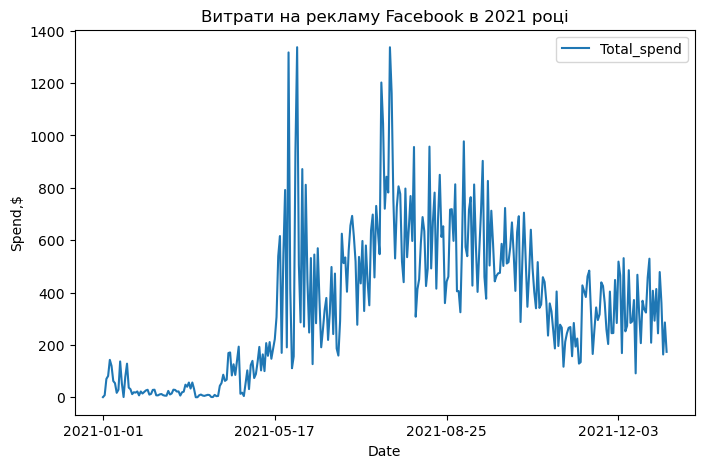

In [ ]:
# 1.1 Графік з щоденною сумою витрат на рекламу у 2021 році

plt.figure(figsize = (8,5), dpi = 100)
plt.plot(daily_stats_2021['ad_date'], daily_stats_2021['total_spend'], label = 'Total_spend')
plt.legend()
plt.title('Витрати на рекламy Facebook в 2021 році')
plt.xlabel('Date')
plt.ylabel('Spend,$')
plt.xticks(list(daily_stats_2021['ad_date'])[::100])
plt.show()

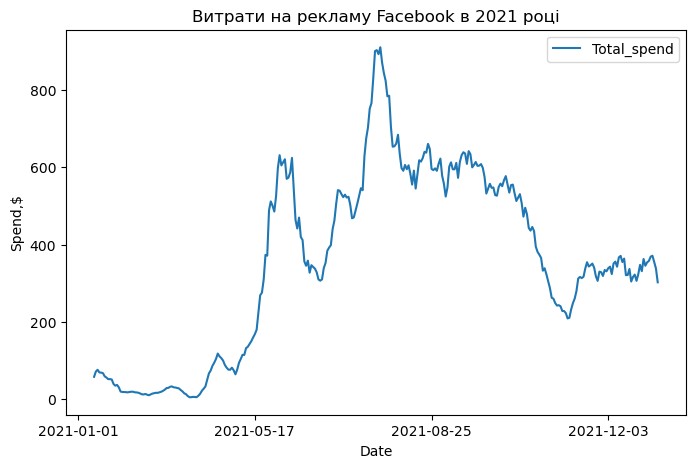

In [ ]:
# 1.1 Графік з щоденною сумою витрат на рекламу у 2021 році. метод rolling().

plt.figure(figsize = (8,5), dpi = 100)
plt.plot(daily_stats_2021['ad_date'], daily_stats_2021['total_spend'].rolling(10).mean(), label = 'Total_spend')
plt.legend()
plt.title('Витрати на рекламy Facebook в 2021 році')
plt.xlabel('Date')
plt.ylabel('Spend,$')
plt.xticks(list(daily_stats_2021['ad_date'])[::100])
plt.show()

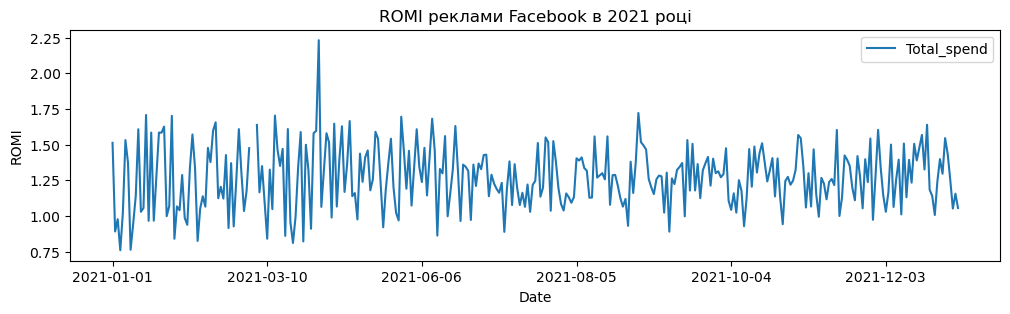

In [ ]:
# 1.2 Графік з щоденним ROMI у 2021 році.
daily_avg_romi = daily_stats_2021.groupby('ad_date')['romi'].mean().reset_index()

plt.figure(figsize = (12,3), dpi = 100)
plt.plot(daily_avg_romi['ad_date'], daily_avg_romi['romi'], label = 'Total_spend')
plt.legend()
plt.title('ROMI реклами Facebook в 2021 році')
plt.xlabel('Date')
plt.ylabel('ROMI')
plt.xticks(list(daily_avg_romi['ad_date'])[::60])
plt.show()

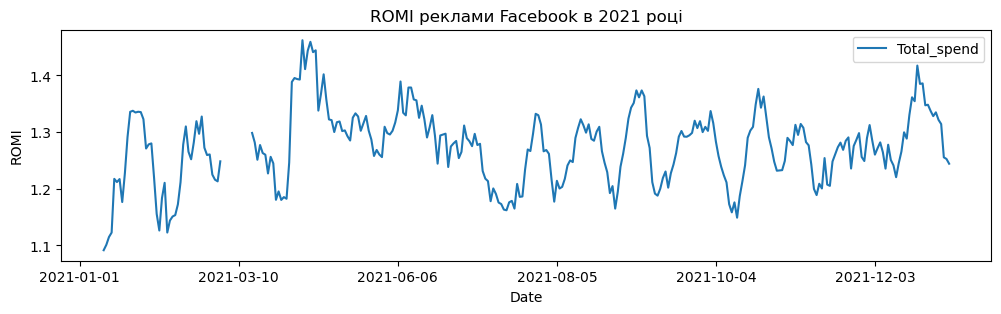

In [ ]:
# 1.2 Графік з щоденним ROMI у 2021 році. метод rolling().

daily_avg_romi = daily_stats_2021.groupby('ad_date')['romi'].mean().reset_index()

plt.figure(figsize = (12,3), dpi = 100)
plt.plot(daily_avg_romi['ad_date'], daily_avg_romi['romi'].rolling(10).mean(), label = 'Total_spend')
plt.legend()
plt.title('ROMI реклами Facebook в 2021 році')
plt.xlabel('Date')
plt.ylabel('ROMI')
plt.xticks(list(daily_avg_romi['ad_date'])[::60])
plt.show()


In [ ]:
# 2. групування даних за назвою кампанії

campaign_stats = df.groupby('campaign_name')[['total_spend', 'total_value']].sum().sort_values(by = ['total_value'])
campaign_stats['romi'] = campaign_stats['total_value'] / campaign_stats['total_spend']
campaign_stats = campaign_stats.reset_index()
campaign_stats


,campaign_name,total_spend,total_value,romi
0,Brand,539.92,670.15,1.241202
1,Crazy discounts,2175.29,2583.59,1.187699
2,Discounts,2856.39,3516.27,1.231019
3,New items,2936.97,3742.05,1.274119
4,Trendy,1992.31,3798.90,1.906782
5,Promos,4993.84,8793.77,1.760923
6,Hobbies,11326.97,13974.63,1.233748
7,Wholesale,14181.71,17421.33,1.228436
8,Electronics,23920.42,29169.38,1.219434
9,Lookalike,63631.09,80234.70,1.260935


<Axes: xlabel='total_spend', ylabel='campaign_name'>

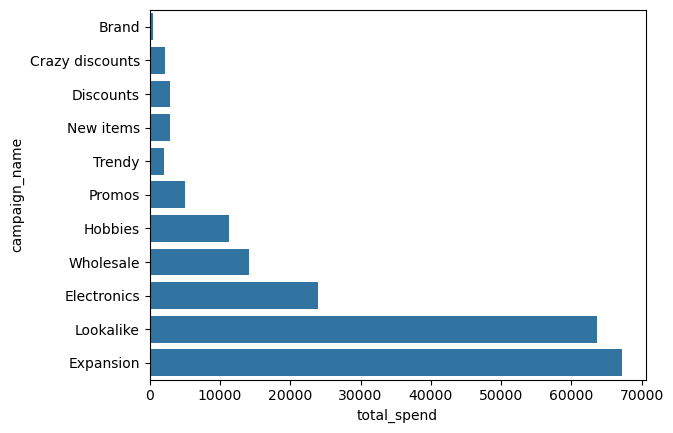

In [ ]:
# 2.1 Графік загальної суми витрат на рекламу в кожній з кампаній:

sns.barplot(data = campaign_stats, x = 'total_spend', y = 'campaign_name')

<Axes: xlabel='romi', ylabel='campaign_name'>

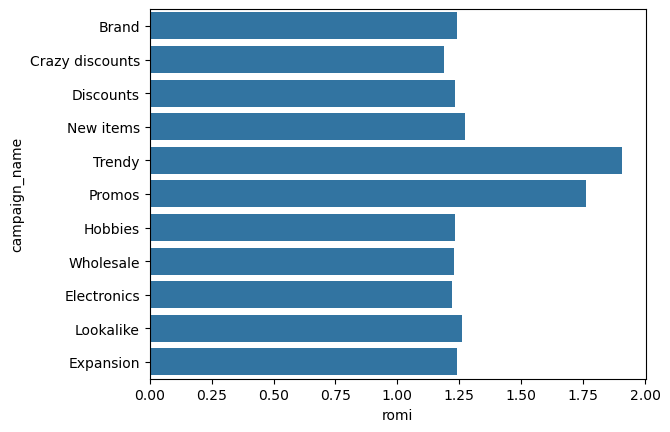

In [ ]:
# 2.2 Загальний ROMI в кожній з кампаній.

sns.barplot(data = campaign_stats, x = 'romi', y = 'campaign_name')

<Axes: xlabel='campaign_name', ylabel='romi'>

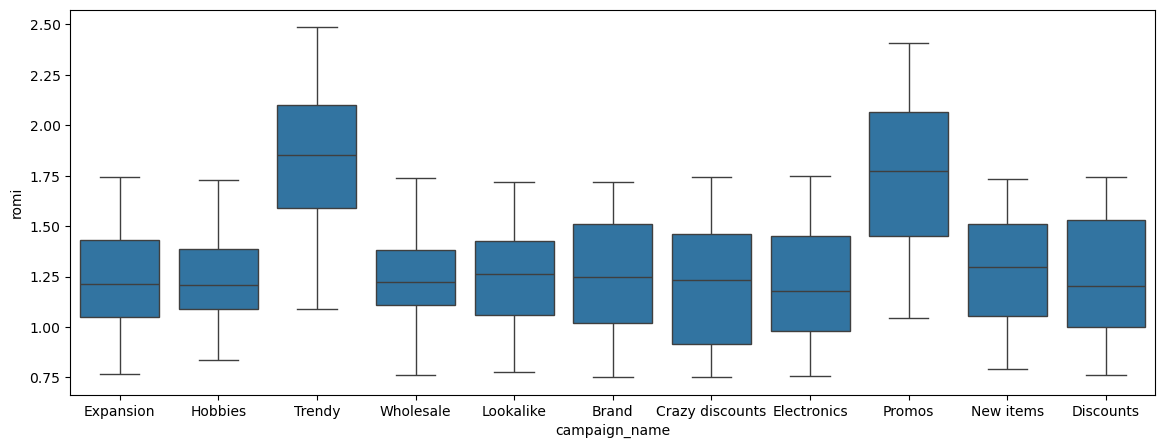

In [ ]:
# 3. розкид щоденного ROMI в кожній кампанії (за назвою кампанії.)

plt.figure(figsize = (14,5), dpi = 100)
sns.boxplot(data = df, y = 'romi', x = 'campaign_name')

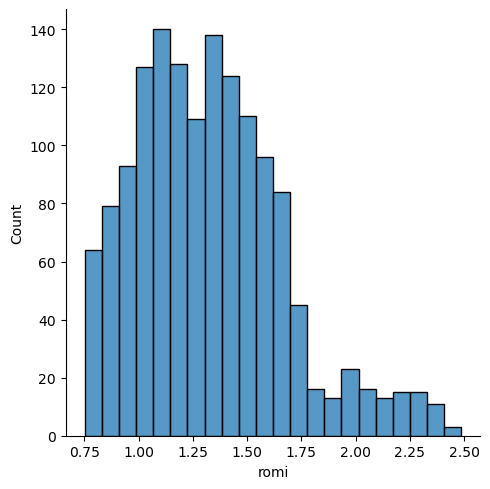

In [ ]:
# 3. гістограмa з розподілом значень ROMI в таблиці facebook_ads_data.csv.

sns.displot(data = df, x = 'romi')

<Axes: >

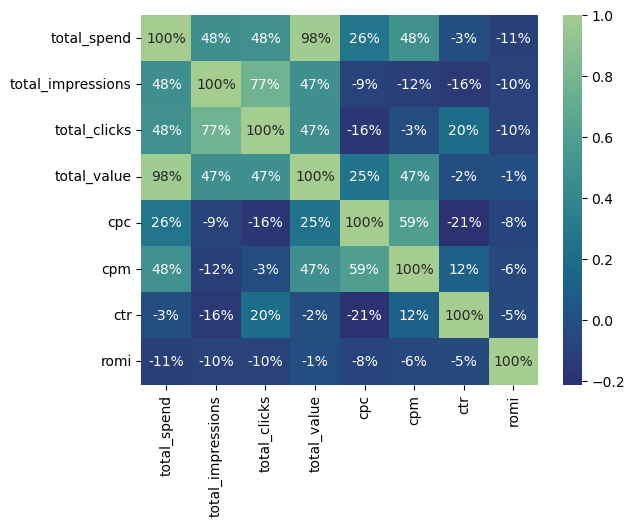

In [ ]:
# 4. тепловa картa кореляції між усіма числовими показниками в таблиці facebook_ads_data.csv.

sns.heatmap(df.corr(numeric_only = True), annot = True, fmt = '.0%', cmap = 'crest_r')

1. Найсильніша кореляція (не рахуючи показників самих із собою) спостерігається між total_spend та total_value. Вона становить 98%. Це логічно: чим більше ви витрачаєте на рекламу, тим вищий загальний дохід отримуєте.
Найнижчий показник (найбільше від’ємне число) — між cpc (ціна за клік) та ctr (клікабельність). Він становить -21%. Це означає, що при зростанні ціни за клік ефективність кліків (CTR) має тенденцію дещо знижуватися.

2. З чим корелює "total_value"? Показник total_value (загальний дохід) має такі основні зв'язки: Майже пряма залежність (98%): з total_spend. Вони зростають практично синхронно. Помірна залежність (47%): з total_impressions, total_clicks та cpm. Це означає, що охоплення та кількість кліків впливають на дохід, але не так прямолінійно, як бюджет. Слабка залежність (25%): з cpc. Відсутність зв'язку: з ctr (-2%) та romi (-1%). Ці показники майже не впливають на загальний дохід у нашому поточному наборі даних.

Цікавий факт: Те, що total_value майже не корелює з romi (-1%), може свідчити про те, що масштабування витрат не обов'язково веде до підвищення рентабельності інвестицій.


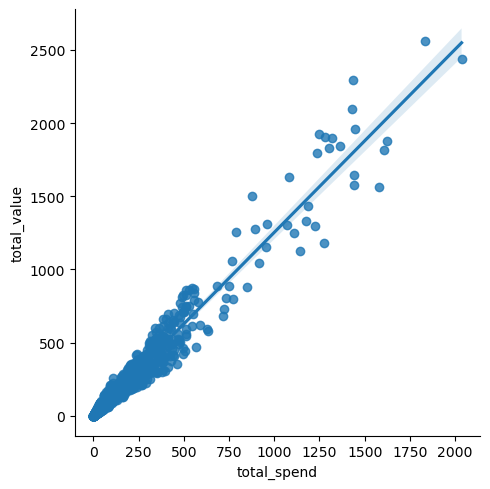

In [ ]:
# 6. точковa діаграмa з лінійною регресією

sns.lmplot(data = df, x = 'total_spend', y = 'total_value')

Побудова точкової діаграми з лінійною регресією візуально підтверджує виявлену раніше сильну кореляцію (98%) між витратами (total_spend) та доходом (total_value).